In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_553/FORS2.2021-08-21T06_02_18.000/Mrk-553_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


In [4]:
image_cut = image[75:175, 0:1890]
image_error_cut = image_error[75:175, 0:1890]

Text(0.5, 0, 'wavelenght')

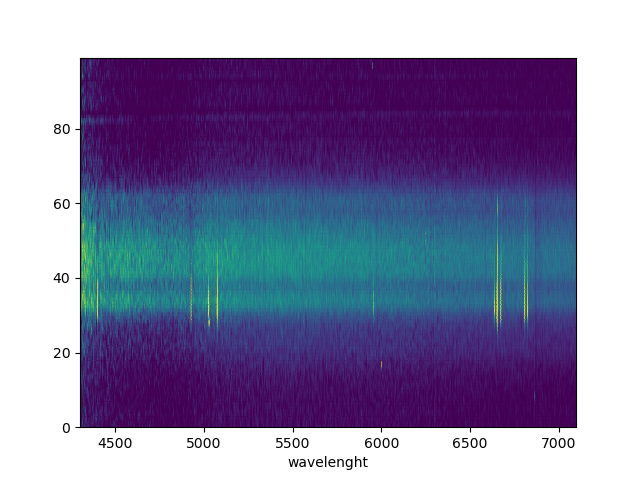

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [6]:
z = 0.01505 
l_HA_z = 6563 * (1+z)
l_HB_z = 4861 * (1+z) 
l_NII_z = 6583 * (1+z)
l_SII_z = 6717 * (1+z)
l_OIII_z = 5007 * (1+z)

l_HA = 6654
l_HB = 4929
l_NII_2 = 6676
l_NII_1 = 6641
l_SII_1 = 6811
l_SII_2 = 6825
l_OIII_1 = 5029
l_OIII_2 = 5077

seeing = 3.174 #in pixels
sigma = seeing/2.35   

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

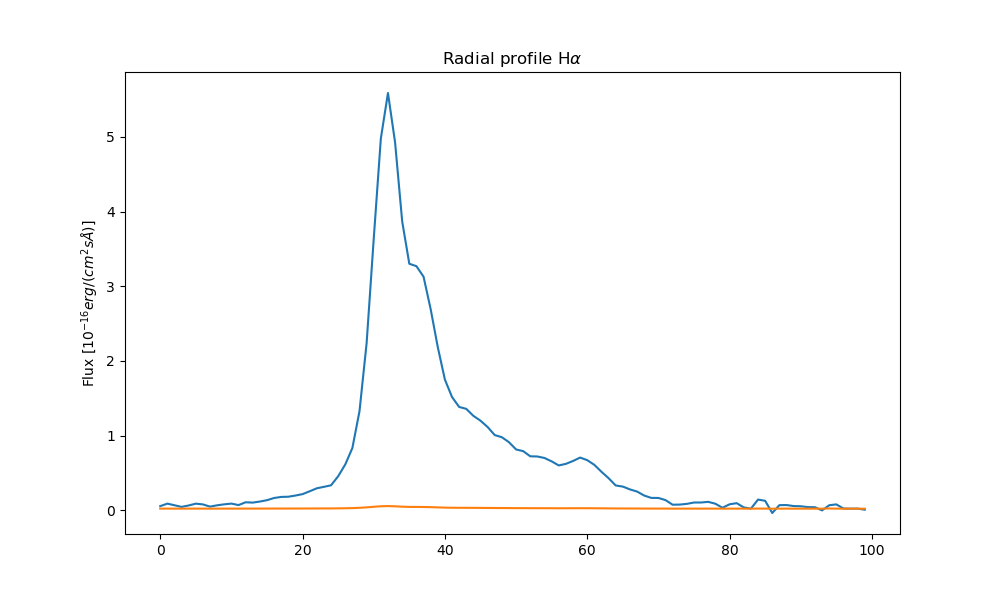

In [7]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

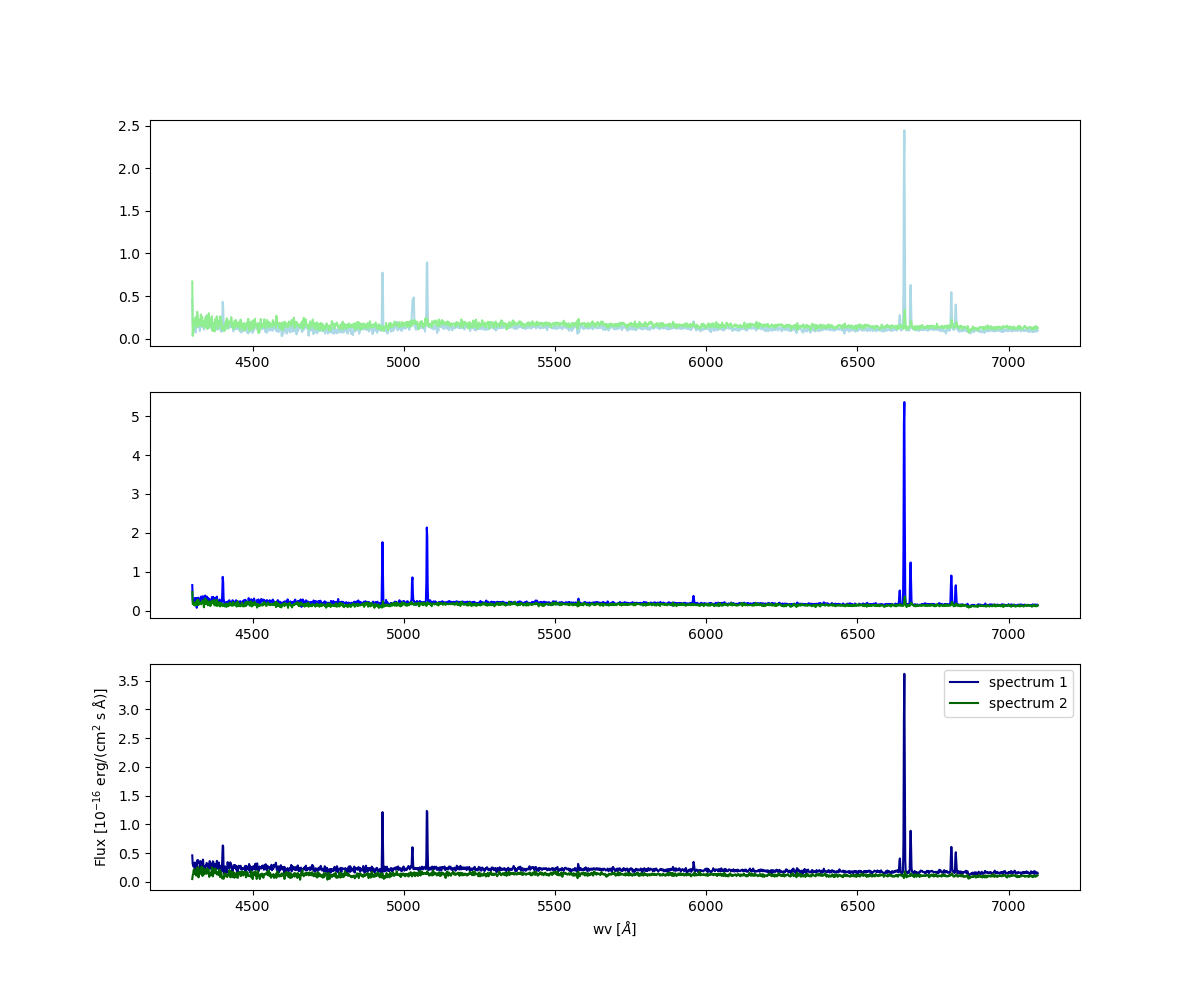

In [8]:
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)
os.makedirs('1s_center', exist_ok=True)

peaks = [32, 60] 

fig, ax = plt.subplots(3, 1, figsize=(12, 10))
spectra_sx =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_c =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_dx =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_sx = np.zeros((len(peaks), image_error_cut.shape[1]))
spectra_err_c = np.zeros((len(peaks), image_error_cut.shape[1]))
spectra_err_dx = np.zeros((len(peaks), image_error_cut.shape[1]))
data_sx = []
data_c = []
data_dx = []
colors_sx =  ['lightblue', 'lightgreen'] #, 'thistle', 'bisque']
colors_c = ['blue', 'green'] #, 'm', 'orange']
colors_dx = ['darkblue', 'darkgreen'] #, 'darkmagenta', 'darkorange']

#Cut one sigma 
for i in range(len(peaks)):
    mask_sx = (x_axes > ((peaks[i]-sigma)-2*sigma))*(x_axes < peaks[i]-sigma)
    mask_c = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    mask_dx = (x_axes > peaks[i]+sigma)*(x_axes < ((peaks[i]+sigma)+2*sigma))
    spectra_sx[i] = np.sum(image_cut[mask_sx, :], axis = 0)
    spectra_c[i] = np.sum(image_cut[mask_c, :], axis = 0)
    spectra_dx[i] = np.sum(image_cut[mask_dx, :], axis = 0)
    spectra_err_sx[i] = np.sqrt(np.sum(image_error_cut[mask_sx, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    spectra_err_c[i] = np.sqrt(np.sum(image_error_cut[mask_c, :]**2, axis = 0))
    spectra_err_dx[i] = np.sqrt(np.sum(image_error_cut[mask_dx, :]**2, axis = 0))
    ax[0].plot(wv, spectra_sx[i], color = colors_sx[i], label = f'spectrum {i+1}')
    ax[1].plot(wv, spectra_c[i], color = colors_c[i], label = f'spectrum {i+1}')
    ax[2].plot(wv, spectra_dx[i], color = colors_dx[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table_sx = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_sx[i].reshape(-1, 1), spectra_err_sx[i].reshape(-1, 1)), axis=1)
    spectrum_table_c = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_c[i].reshape(-1, 1), spectra_err_c[i].reshape(-1, 1)), axis=1)
    spectrum_table_dx = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_dx[i].reshape(-1, 1), spectra_err_dx[i].reshape(-1, 1)), axis=1)
    data_sx.append(spectrum_table_sx)
    data_c.append(spectrum_table_c)
    data_dx.append(spectrum_table_dx)
    
np.savetxt(os.path.join('1s_center', 'Spectrum_sx_1.txt'), data_sx[0])
np.savetxt(os.path.join('1s_center', 'Spectrum_sx_2.txt'), data_sx[1])
#np.savetxt(os.path.join('1s_center', 'Spectrum_sx_3.txt'), data_sx[2])
#np.savetxt(os.path.join('1s_center', 'Spectrum_sx_4.txt'), data_sx[3])

np.savetxt(os.path.join('1s_center', 'Spectrum_center_1.txt'), data_c[0])
np.savetxt(os.path.join('1s_center', 'Spectrum_center_2.txt'), data_c[1])
#np.savetxt(os.path.join('1s_center', 'Spectrum_center_3.txt'), data_c[2])
#np.savetxt(os.path.join('1s_center', 'Spectrum_center_4.txt'), data_c[3])

np.savetxt(os.path.join('1s_center', 'Spectrum_dx_1.txt'), data_dx[0])
np.savetxt(os.path.join('1s_center', 'Spectrum_dx_2.txt'), data_dx[1])
#np.savetxt(os.path.join('1s_center', 'Spectrum_dx_3.txt'), data_dx[2])
#np.savetxt(os.path.join('1s_center', 'Spectrum_dx_4.txt'), data_dx[3])

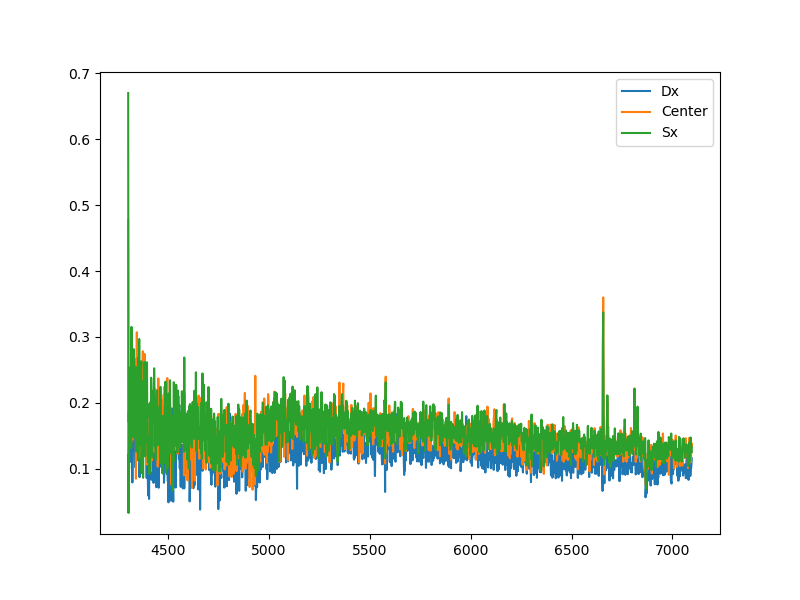

In [9]:
plt.figure(figsize=(8,6))
plt.plot(wv, spectra_dx[1], label = 'Dx')
plt.plot(wv, spectra_c[1], label = 'Center')
plt.plot(wv, spectra_sx[1], label = 'Sx')
plt.legend()

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [10]:
# Definizione delle maschere per i continui
mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6000)*(wv < 6500)
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_sx[i, mask_continuum_1])
    noise_1 = np.std(spectra_sx[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_sx[i, mask_continuum_2])
    noise_2 = np.std(spectra_sx[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_sx[i, mask_continuum_3])
    noise_3 = np.std(spectra_sx[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
    
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
os.path.join('1s_center', 'SNR_c_continuum.csv')
df_path_snr = os.path.join('1s_center', 'SNR_sx_continuum.csv')
df_path_signal = os.path.join('1s_center', 'Signal_sx_continuum.csv')
df_path_noise = os.path.join('1s_center', 'Noise_sx_continuum.csv')
df_path_combined = os.path.join('1s_center', 'Combined_sx_continuum.csv')
# Assicurati che la directory esista
os.makedirs('1s_center', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2
Continuum_1    3.545681    4.960625
Continuum_2    7.353799    9.382193
Continuum_3    6.992691    9.104236

DataFrame Signal:
             Spectrum_1  Spectrum_2
Continuum_1    0.116189    0.159129
Continuum_2    0.133762    0.167845
Continuum_3    0.113883    0.147788

DataFrame Noise:
             Spectrum_1  Spectrum_2
Continuum_1    0.032769    0.032078
Continuum_2    0.018190    0.017890
Continuum_3    0.016286    0.016233

DataFrame Combinato:
                   SNR                Signal                 Noise           
            Spectrum_1 Spectrum_2 Spectrum_1 Spectrum_2 Spectrum_1 Spectrum_2
Continuum_1   3.545681   4.960625   0.116189   0.159129   0.032769   0.032078
Continuum_2   7.353799   9.382193   0.133762   0.167845   0.018190   0.017890
Continuum_3   6.992691   9.104236   0.113883   0.147788   0.016286   0.016233

File salvati in:
- 1s_center\SNR_sx_continuum.csv
- 1s_center\Signal_sx_continuum.csv
- 1s_center\Noise

In [11]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_c[i, mask_continuum_1])
    noise_1 = np.std(spectra_c[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_c[i, mask_continuum_2])
    noise_2 = np.std(spectra_c[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_c[i, mask_continuum_3])
    noise_3 = np.std(spectra_c[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T
# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
df_path_snr = os.path.join('1s_center', 'SNR_c_continuum.csv')
df_path_signal = os.path.join('1s_center', 'Signal_c_continuum.csv')
df_path_noise = os.path.join('1s_center', 'Noise_c_continuum.csv')
df_path_combined = os.path.join('1s_center', 'Combined_c_continuum.csv')
# Assicurati che la directory esista
os.makedirs('1s_center', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2
Continuum_1    5.712571    4.939715
Continuum_2    9.654995    8.854806
Continuum_3   10.056498    8.107509

DataFrame Signal:
             Spectrum_1  Spectrum_2
Continuum_1    0.208974    0.149356
Continuum_2    0.195753    0.161697
Continuum_3    0.168137    0.141885

DataFrame Noise:
             Spectrum_1  Spectrum_2
Continuum_1    0.036581    0.030236
Continuum_2    0.020275    0.018261
Continuum_3    0.016719    0.017500

DataFrame Combinato:
                   SNR                Signal                 Noise           
            Spectrum_1 Spectrum_2 Spectrum_1 Spectrum_2 Spectrum_1 Spectrum_2
Continuum_1   5.712571   4.939715   0.208974   0.149356   0.036581   0.030236
Continuum_2   9.654995   8.854806   0.195753   0.161697   0.020275   0.018261
Continuum_3  10.056498   8.107509   0.168137   0.141885   0.016719   0.017500

File salvati in:
- 1s_center\SNR_c_continuum.csv
- 1s_center\Signal_c_continuum.csv
- 1s_center\Noise_c

In [12]:
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(len(peaks)):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra_dx[i, mask_continuum_1])
    noise_1 = np.std(spectra_dx[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra_dx[i, mask_continuum_2])
    noise_2 = np.std(spectra_dx[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra_dx[i, mask_continuum_3])
    noise_3 = np.std(spectra_dx[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T
# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(len(peaks))]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
df_path_snr = os.path.join('1s_center', 'SNR_dx_continuum.csv')
df_path_signal = os.path.join('1s_center', 'Signal_dx_continuum.csv')
df_path_noise = os.path.join('1s_center', 'Noise_dx_continuum.csv')
df_path_combined = os.path.join('1s_center', 'Combined_dx_continuum.csv')
# Assicurati che la directory esista
os.makedirs('1s_center', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2
Continuum_1    6.867652    3.761520
Continuum_2   10.971569    7.589666
Continuum_3   10.351859    7.706140

DataFrame Signal:
             Spectrum_1  Spectrum_2
Continuum_1    0.231411    0.119384
Continuum_2    0.219350    0.136655
Continuum_3    0.188927    0.116274

DataFrame Noise:
             Spectrum_1  Spectrum_2
Continuum_1    0.033696    0.031738
Continuum_2    0.019993    0.018005
Continuum_3    0.018251    0.015088

DataFrame Combinato:
                   SNR                Signal                 Noise           
            Spectrum_1 Spectrum_2 Spectrum_1 Spectrum_2 Spectrum_1 Spectrum_2
Continuum_1   6.867652   3.761520   0.231411   0.119384   0.033696   0.031738
Continuum_2  10.971569   7.589666   0.219350   0.136655   0.019993   0.018005
Continuum_3  10.351859   7.706140   0.188927   0.116274   0.018251   0.015088

File salvati in:
- 1s_center\SNR_dx_continuum.csv
- 1s_center\Signal_dx_continuum.csv
- 1s_center\Noise

## S/N emission lines 

In [13]:
def SNR_line(wv, wv_line, spectra, peaks):
    left_region = (wv > wv_line-25)*(wv < wv_line-10) 
    right_region = (wv > wv_line+10)*(wv < wv_line+25) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise

def SNR_SII_line(wv, wv_line, spectra, peaks):
    left_region = (wv > 6805-15)*(wv < 6805) 
    right_region = (wv > 6831)*(wv < 6831+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, wv_line, spectra, peaks):
    left_region = (wv > 6620) & (wv < 6635)
    right_region = (wv > 6780) & (wv < 6795)
    clean_mask = left_region | right_region #But also for the two NII lines bc they are closed

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))

    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise  

In [14]:
index = ['Component_1', 'Component_2'] #, 'Component_3', 'Component_4']
SNR_HB_1, signal_HB_1, noise_HB_1 = SNR_line(wv, l_HB, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_HB_1).reshape(-1, 1),
    np.array(signal_HB_1).reshape(-1, 1),
    np.array(noise_HB_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index )
df_path = os.path.join('1s_center', 'SNR_HB_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_2, signal_HB_2, noise_HB_2 = SNR_line(wv, l_HB, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_HB_2).reshape(-1, 1),
    np.array(signal_HB_2).reshape(-1, 1),
    np.array(noise_HB_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_HB_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_3, signal_HB_3, noise_HB_3 = SNR_line(wv, l_HB, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_HB_3).reshape(-1, 1),
    np.array(signal_HB_3).reshape(-1, 1),
    np.array(noise_HB_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_HB_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_1, signal_SII_1, noise_SII_1 = SNR_SII_line(wv, l_SII_1, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_SII_1).reshape(-1, 1),
    np.array(signal_SII_1).reshape(-1, 1),
    np.array(noise_SII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_1_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2, signal_SII_2, noise_SII_2 = SNR_SII_line(wv, l_SII_1, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_SII_2).reshape(-1, 1),
    np.array(signal_SII_2).reshape(-1, 1),
    np.array(noise_SII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_1_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_3, signal_SII_3, noise_SII_3 = SNR_SII_line(wv, l_SII_1, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_SII_3).reshape(-1, 1),
    np.array(signal_SII_3).reshape(-1, 1),
    np.array(noise_SII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_1_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_1, signal_SII_2_1, noise_SII_2_1 = SNR_SII_line(wv, l_SII_2, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_1).reshape(-1, 1),
    np.array(signal_SII_2_1).reshape(-1, 1),
    np.array(noise_SII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_2_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_2, signal_SII_2_2, noise_SII_2_2 = SNR_SII_line(wv, l_SII_2, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_2).reshape(-1, 1),
    np.array(signal_SII_2_2).reshape(-1, 1),
    np.array(noise_SII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_2_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2_3, signal_SII_2_3, noise_SII_2_3 = SNR_SII_line(wv, l_SII_2, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_SII_2_3).reshape(-1, 1),
    np.array(signal_SII_2_3).reshape(-1, 1),
    np.array(noise_SII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_SII_2_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_1, signal_OIII_1, noise_OIII_1 = SNR_line(wv, l_OIII_1, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_1).reshape(-1, 1),
    np.array(signal_OIII_1).reshape(-1, 1),
    np.array(noise_OIII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_1_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2, signal_OIII_2, noise_OIII_2 = SNR_line(wv, l_OIII_1, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2).reshape(-1, 1),
    np.array(signal_OIII_2).reshape(-1, 1),
    np.array(noise_OIII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_1_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_3, signal_OIII_3, noise_OIII_3 = SNR_line(wv, l_OIII_1, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_3).reshape(-1, 1),
    np.array(signal_OIII_3).reshape(-1, 1),
    np.array(noise_OIII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_1_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_1, signal_OIII_2_1, noise_OIII_2_1 = SNR_line(wv, l_OIII_2, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_1).reshape(-1, 1),
    np.array(signal_OIII_2_1).reshape(-1, 1),
    np.array(noise_OIII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_2_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_2, signal_OIII_2_2, noise_OIII_2_2 = SNR_line(wv, l_OIII_2, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_2).reshape(-1, 1),
    np.array(signal_OIII_2_2).reshape(-1, 1),
    np.array(noise_OIII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_2_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2_3, signal_OIII_2_3, noise_OIII_2_3 = SNR_line(wv, l_OIII_2, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2_3).reshape(-1, 1),
    np.array(signal_OIII_2_3).reshape(-1, 1),
    np.array(noise_OIII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_OIII_2_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_1, signal_HA_1, noise_HA_1 = SNR_HA_NII(wv, l_HA, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_HA_1).reshape(-1, 1),
    np.array(signal_HA_1).reshape(-1, 1),
    np.array(noise_HA_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_HA_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_2, signal_HA_2, noise_HA_2 = SNR_HA_NII(wv, l_HA, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_HA_2).reshape(-1, 1),
    np.array(signal_HA_2).reshape(-1, 1),
    np.array(noise_HA_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_HA_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_3, signal_HA_3, noise_HA_3 = SNR_HA_NII(wv, l_HA, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_HA_3).reshape(-1, 1),
    np.array(signal_HA_3).reshape(-1, 1),
    np.array(noise_HA_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_HA_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_1, signal_NII_1, noise_NII_1 = SNR_HA_NII(wv, l_NII_1, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_NII_1).reshape(-1, 1),
    np.array(signal_NII_1).reshape(-1, 1),
    np.array(noise_NII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_1_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2, signal_NII_2, noise_NII_2 = SNR_HA_NII(wv, l_NII_1, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_NII_2).reshape(-1, 1),
    np.array(signal_NII_2).reshape(-1, 1),
    np.array(noise_NII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_1_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_3, signal_NII_3, noise_NII_3 = SNR_HA_NII(wv, l_NII_1, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_NII_3).reshape(-1, 1),
    np.array(signal_NII_3).reshape(-1, 1),
    np.array(noise_NII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_1_dx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_1, signal_NII_2_1, noise_NII_2_1 = SNR_HA_NII(wv, l_NII_2, spectra_sx, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_1).reshape(-1, 1),
    np.array(signal_NII_2_1).reshape(-1, 1),
    np.array(noise_NII_2_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_2_sx.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_2, signal_NII_2_2, noise_NII_2_2 = SNR_HA_NII(wv, l_NII_2, spectra_c, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_2).reshape(-1, 1),
    np.array(signal_NII_2_2).reshape(-1, 1),
    np.array(noise_NII_2_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_2_c.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2_3, signal_NII_2_3, noise_NII_2_3 = SNR_HA_NII(wv, l_NII_2, spectra_dx, peaks)
data = np.concatenate([
    np.array(SNR_NII_2_3).reshape(-1, 1),
    np.array(signal_NII_2_3).reshape(-1, 1),
    np.array(noise_NII_2_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = index)
df_path = os.path.join('1s_center', 'SNR_NII_2_dx.csv')
df.to_csv(df_path, float_format='%.3f')